In [1]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# ============================================
# 2. Load Data
# ============================================

male_file = "male_file.xlsx"
female_file = "female_file.xlsx"

male = pd.read_excel(male_file)
female = pd.read_excel(female_file)

data = pd.concat([male, female], ignore_index=True)

# Clean column names
data.columns = data.columns.str.strip()

In [3]:
# ============================================
# 3. Encode Sex
# ============================================

data["Sex"] = data["Sex"].map({"M":0, "F":1})

In [4]:
# ============================================
# 4. Build Tree-Level Dataset
# ============================================

# Mean values per tree
tree_mean = data.groupby("Tree_ID").mean(numeric_only=True)

# Variability per tree
tree_std = data.groupby("Tree_ID").std(numeric_only=True)

# Combine mean + std
tree_dataset = tree_mean.join(tree_std, rsuffix="_std")

# Add sex information
tree_sex = data.groupby("Tree_ID")["Sex"].first()

tree_dataset["Sex"] = tree_sex


print("Tree-level dataset shape:", tree_dataset.shape)

Tree-level dataset shape: (172, 24)


In [5]:
# ============================================
# 5. Prepare ML Dataset
# ============================================

X = tree_dataset.drop(columns=["Sex"])
y = tree_dataset["Sex"]

In [6]:
# ============================================
# 6. Train/Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [7]:
# ============================================
# 7. Train Random Forest
# ============================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(n_estimators=500, random_state=42))])

In [8]:
# ============================================
# 8. Extract Feature Importance
# ============================================

rf_model = pipeline.named_steps["model"]

importance = rf_model.feature_importances_

feature_names = X.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [9]:
# ============================================
# 9. Display Top Features
# ============================================

print("\nTop 15 Important Features:\n")
print(importance_df.head(15))


Top 15 Important Features:

                          Feature  Importance
15            largeur_petiole_std    0.082732
14           Longueur_petiole_std    0.069011
17            Largeur_foliole_std    0.063296
4                 largeur_petiole    0.056200
16           Longueur_foliole_std    0.056185
18  Longueur-Largeur_folioles_std    0.051261
8                 Nombre_folioles    0.049466
11           Longueur_feuille_std    0.046977
5                Longueur_foliole    0.046924
13             longueur_limbe_std    0.046632
20        Longueur_entre_nœud_std    0.046450
12              Largeur_limbe_std    0.043000
3                Longueur_petiole    0.041624
6                 Largeur_foliole    0.041016
0                Longueur_feuille    0.037764


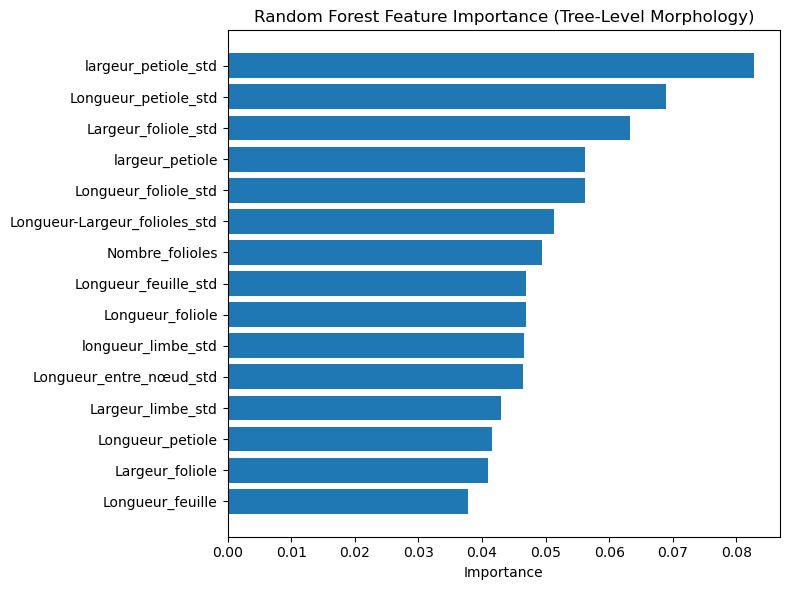

In [10]:
# ============================================
# 10. Plot Feature Importance
# ============================================

plt.figure(figsize=(8,6))

top_features = importance_df.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance (Tree-Level Morphology)")
plt.xlabel("Importance")

plt.tight_layout()

plt.show()